In [1]:
%matplotlib inline
from pylab import *

In [2]:
from deficit_defs_2025_02_25 import *

Splikes version  0.1.4
Plasticnet version  0.1.12
macOS-15.3.2-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [3]:
number_of_processes=8
ray.init(num_cpus=number_of_processes)

2025-04-07 19:31:21,382	INFO worker.py:1841 -- Started a local Ray instance.


Python version:,3.12.6
Ray version:,2.43.0


In [4]:
base_sim_dir=f"sims-2025-04-07"
if not os.path.exists(base_sim_dir):
    os.mkdir(base_sim_dir)
print(base_sim_dir)

sims-2025-04-07


In [5]:
def default_post(number_of_neurons,y_min=0,y_max=50):
    post=pn.neurons.linear_neuron(number_of_neurons)
    post+=pn.neurons.process.sigmoid(y_min,y_max)
    return post

def default_bcm(pre,post,orthogonalization=True):
    c=pn.connections.BCM(pre,post,[-.01,.01],[.1,.2])
    
    if orthogonalization:
        c+=pn.connections.process.orthogonalization(10*minute)

    c.eta=2e-6
    c.tau=15*pn.minute   

    return c

In [6]:
dt=200*ms
rf_size=19
blur=[3.5,0]
eta=2e-6
mu_c=mu_r=sigma_r=sigma_c=0

seq=pn.Sequence()

im=[]
for b in blur:
    if b<0:
        im+=[pi5.filtered_images(base_image_file,
                                {'type':'norm'},
                                {'type':'dog','sd1':1,'sd2':3},   
                                verbose=True,
                                )
            ]
    else:
        im+=[pi5.filtered_images(base_image_file,
                                {'type':'blur','size':b},
                                {'type':'norm'},
                                {'type':'dog','sd1':1,'sd2':3},   
                                verbose=True,
                                    )
            ]


pre1=pn.neurons.natural_images_with_jitter(im[0],
                               rf_size=rf_size,
                                            sigma_r=0,
                                            sigma_c=0,
                                   verbose=False)

pre2=pn.neurons.natural_images_with_jitter(im[1],rf_size=rf_size,
                            other_channel=pre1,
                                mu_r=mu_r,mu_c=mu_c,
                                sigma_r=sigma_r,sigma_c=sigma_c,
                            verbose=False)



sigma=0.1
pre1+=pn.neurons.process.add_noise_normal(0,sigma)
pre2+=pn.neurons.process.add_noise_normal(0,sigma)

pre=pre1+pre2

number_of_neurons=12

post=default_post(number_of_neurons)
c=default_bcm(pre,post)
c.eta=eta

total_time=8*day
save_interval=1*hour
sim=pn.simulation(total_time)
sim.dt=dt

sim.monitor(post,['output'],save_interval)
sim.monitor(c,['weights','theta'],save_interval)

rf_diameter=rf_size
cpd=2**linspace(-4,3,20)
deg_per_pixel=1/rf_diameter  # <=============
k_mat=2*pi*cpd*deg_per_pixel
    
sim+=pn.grating_response(print_time=False,
                    k_mat=k_mat,
                        )


seq+=sim,[pre,post],[c]


seq.run(display_hash=True)

final_weights=c.weights.copy()

sfname=f"{base_sim_dir}/rf1.asdf"
pn.save(sfname,seq) 

 [#############################99% (ETA: 0.6 s)############################# ].] Sequence Time Elapsed...1 m, 2.51 s840f1e603d853993b64b8575a6166.asdf from cache.[


In [7]:
def setminmax(data,min=None,max=None):
    data=data.copy()
    
    if min is None:
        min=data.min()
    if max is None:
        max=data.max()
        
    mn=data.min()
    mx=data.max()
    
    data-=mn
    data/=(mx-mn)
    data*=(max-min)
    data+=min

    return data

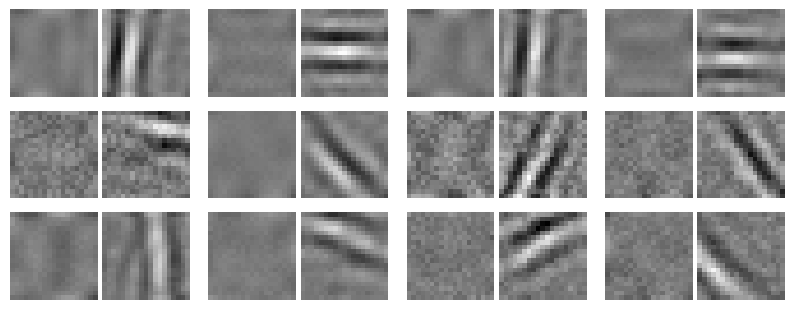

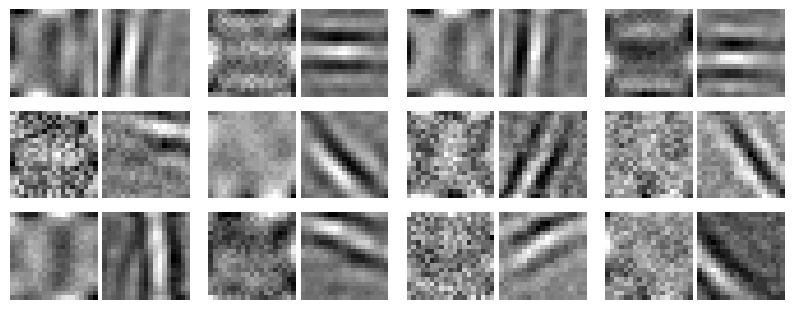

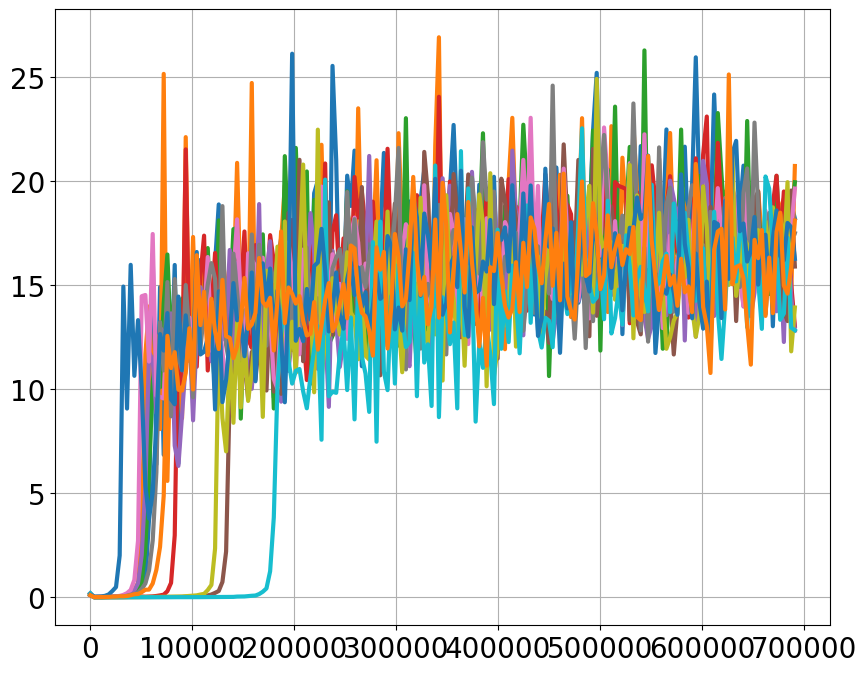

In [8]:
neurons,connections=[pre,post],[c]

c=connections[0]

weights=c.weights
num_neurons=len(weights)
rf_size=neurons[0].neuron_list[0].rf_size

W=weights.reshape((num_neurons,
                    2,
                    rf_size,rf_size))

vmin,vmax=W.min(),W.max()

count=0
blocks=[]
for row in range(3):
    block_row=[]
    for col in range(4):

        for channel in range(2):
            rf=W[count,channel,:,:]
            block_row.append(rf)
            if channel<(2-1):
                block_row.append(vmax*ones((rf_size,1)))

        if col<4-1:
            block_row.append(vmax*ones((rf_size,4)))
    
        count+=1

    blocks.append(block_row)

    buffer_row=[vmax*ones((3,_.shape[1])) for _ in block_row]
    if row<3-1:
        blocks.append(buffer_row)


im=np.block(blocks)

figure()
imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
grid(None)
axis('off')

#===== try with scaling every channel to the max range

count=0
blocks=[]
for row in range(3):
    block_row=[]
    for col in range(4):

        for channel in range(2):
            rf=W[count,channel,:,:]
            rf=setminmax(rf,vmin,vmax)
            
            block_row.append(rf)
            if channel<(2-1):
                block_row.append(vmax*ones((rf_size,1)))

        if col<4-1:
            block_row.append(vmax*ones((rf_size,4)))
    
        count+=1

    blocks.append(block_row)

    buffer_row=[vmax*ones((3,_.shape[1])) for _ in block_row]
    if row<3-1:
        blocks.append(buffer_row)


im=np.block(blocks)

figure()
imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
grid(None)
axis('off')






figure()
t,θ=sim.monitors['theta'].arrays()
plot(t,θ);

In [187]:
R=Results(sfname)

In [188]:
subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]


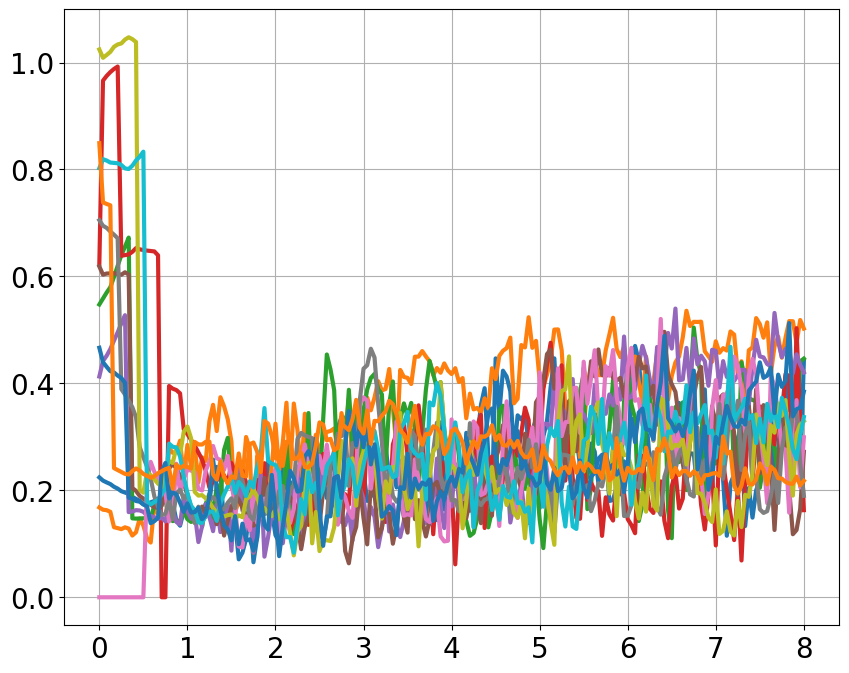

In [189]:
plot(subR.t,subR.LSFV[:,:,0]);

In [190]:
t,y=R.all_responses[0]
y.shape   # SF, theta, channels, neurons, time

(20, 24, 2, 12, 193)

In [191]:
# end time
y=y[:,:,:,:,-1]
y.shape

(20, 24, 2, 12)

In [192]:
ch_idx=[]
for channel in range(2):
    idx=[]
    for n in range(y.shape[3]):
        idx+=[argmax(y[:,:,channel,n])]  # max across all angles and SF
    ch_idx.append(idx)
print(ch_idx)

[[360, 338, 352, 331, 321, 320, 317, 342, 292, 352, 318, 319], [360, 385, 373, 365, 373, 369, 382, 370, 354, 374, 379, 377]]


In [193]:
theta_mat=subR.theta_mat
k_mat=subR.k_mat
len(theta_mat),len(k_mat)

(24, 20)

In [194]:
ch_result=[]

for channel in range(2):
    idx=ch_idx[channel]
    
    i,j=meshgrid(range(len(theta_mat)),range(len(k_mat)))
    _S=Storage()
    
    max_k_idx=[]
    max_theta_idx=[]
    
    for n in range(y.shape[3]):
        max_k_idx=j.ravel()[idx[n]]
        max_theta_idx=i.ravel()[idx[n]]
        max_k=k_mat[max_k_idx]
        max_theta=theta_mat[max_theta_idx]
    
        _S+=max_k,max_theta,max_k_idx,max_theta_idx
    
    max_k,max_theta,max_k_idx,max_theta_idx=_S.arrays()

    ch_result.append( [max_k,max_theta,max_k_idx,max_theta_idx] )

ch_result[0][:2]

[array([0.95256167, 0.73788268, 0.73788268, 0.57158593, 0.57158593,
        0.57158593, 0.57158593, 0.73788268, 0.4427675 , 0.73788268,
        0.57158593, 0.57158593]),
 array([  0.        ,  15.65217391, 125.2173913 , 148.69565217,
         70.43478261,  62.60869565,  39.13043478,  46.95652174,
         31.30434783, 125.2173913 ,  46.95652174,  54.7826087 ])]

In [195]:
def mysubplot(nr,nc,r,c=None):
    from pylab import subplot,subplot2grid

    if c is None:
        subplot(nr,nc,r)
        return
    
    subplot2grid((nr,nc),(r-1,c-1))
    return


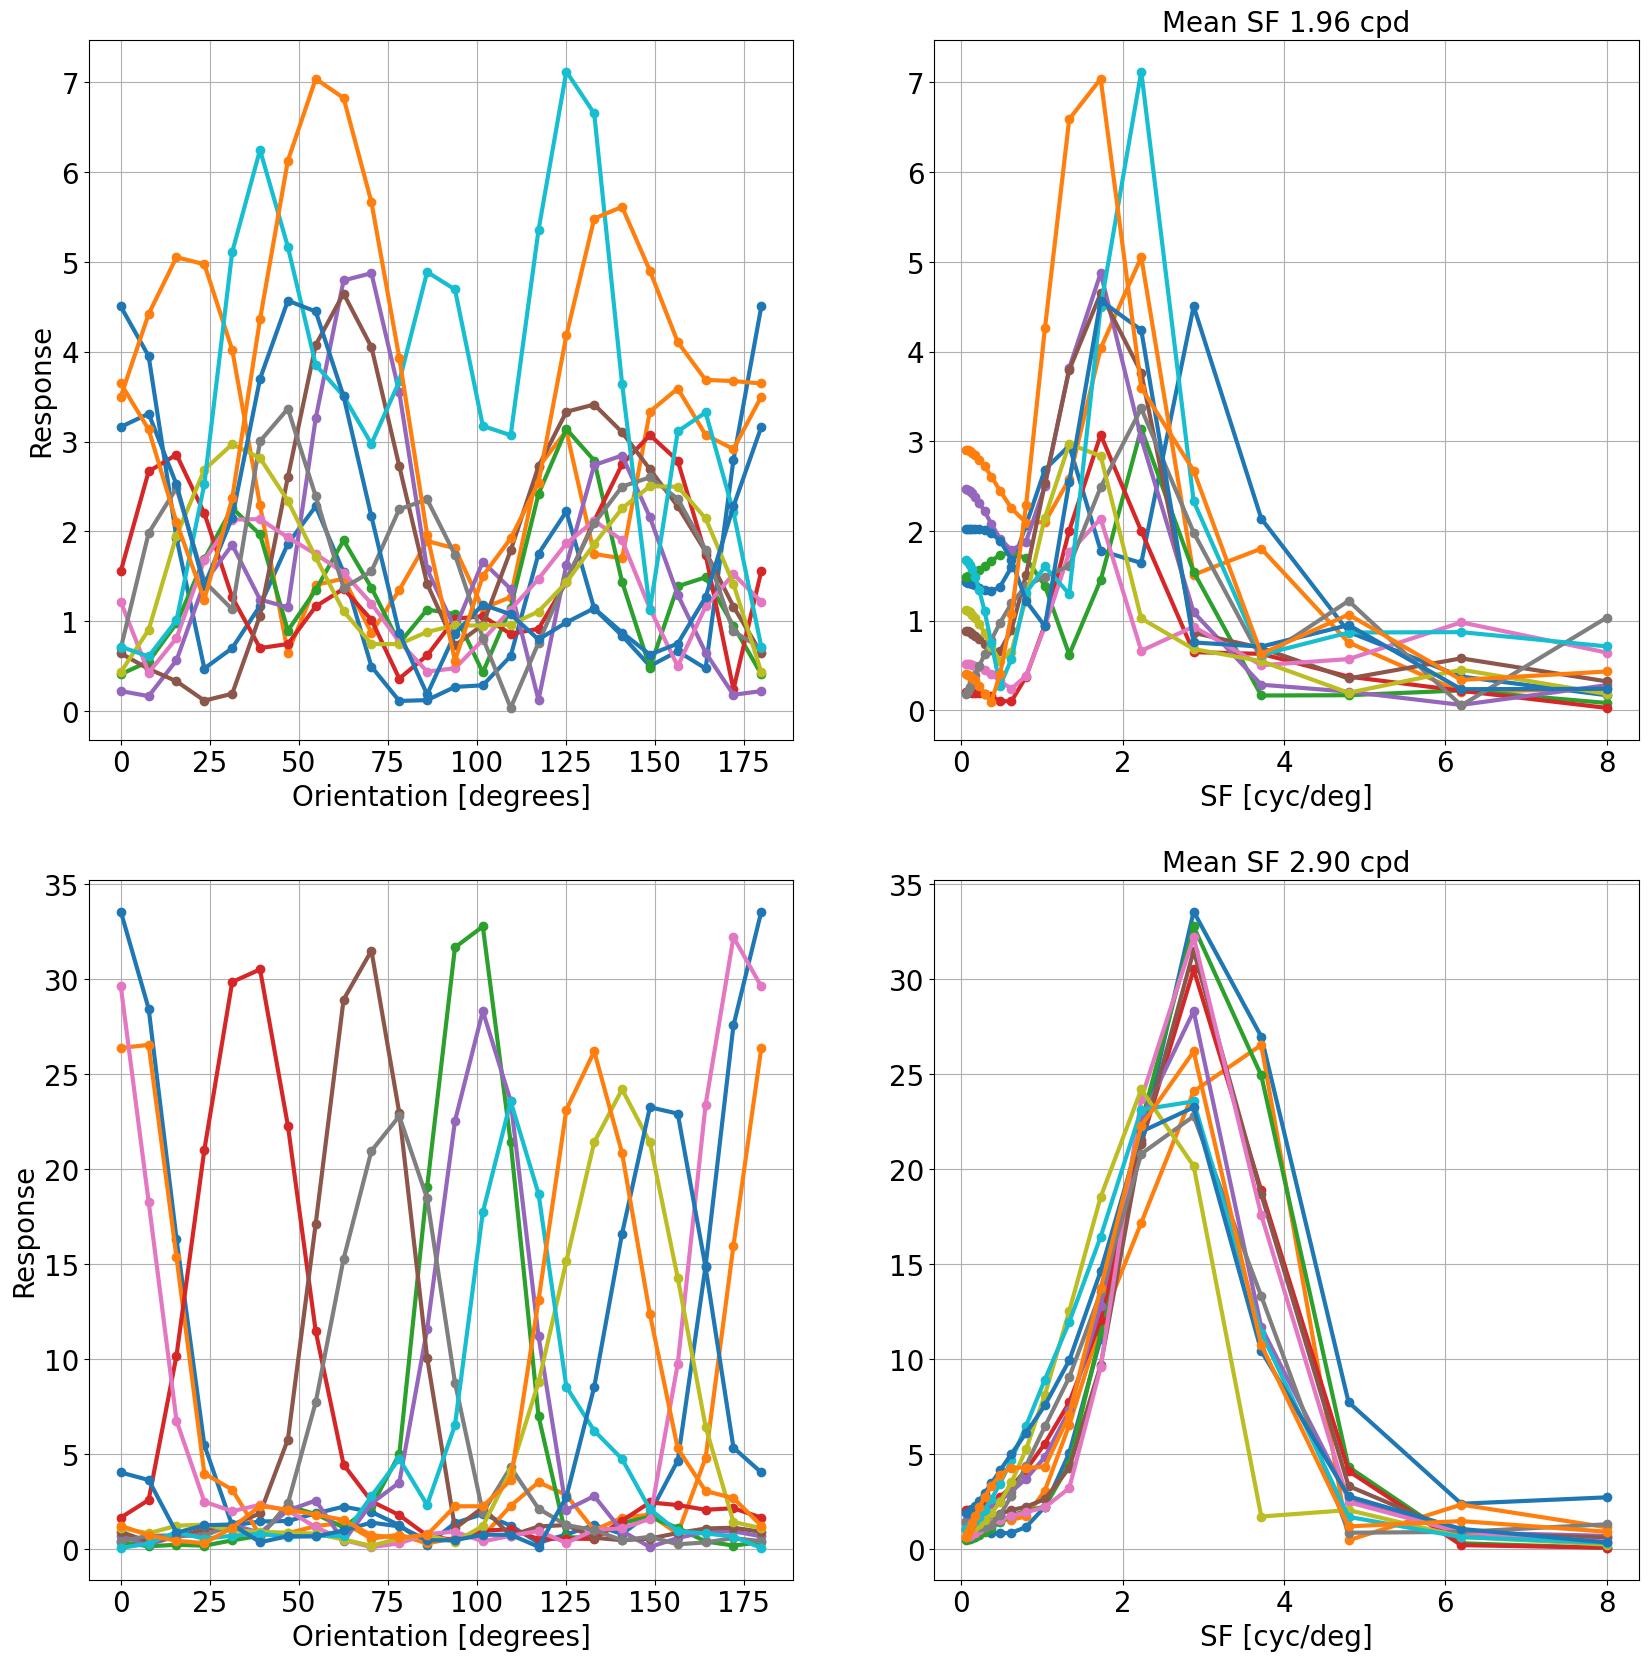

In [196]:
figure(figsize=(20,20))
for channel in range(2):
    max_k,max_theta,max_k_idx,max_theta_idx=ch_result[channel]
    
    mysubplot(2,2,channel+1,1)
    
    for n in range(y.shape[3]):
        plot(theta_mat,y[:,:,channel,n][max_k_idx[n],:],'-o')
    xlabel('Orientation [degrees]')
    ylabel('Response')
    
    cpd=k_mat/(2*pi*deg_per_pixel)
    max_cpd=max_k/(2*pi*deg_per_pixel)
    mysubplot(2,2,channel+1,2)

    for n in range(y.shape[3]):
        plot(cpd,y[:,:,channel,n][:,max_theta_idx[n]],'-o')
    
    xlabel('SF [cyc/deg]')
    title(f'Mean SF {mean(max_cpd):.2f} cpd')

    

In [197]:
y.shape

(20, 24, 2, 12)

In [198]:
rf_diameter=rf_size
cpd=2**linspace(-4,3,20)
deg_per_pixel=1/rf_diameter  # <=============
k_mat=2*pi*cpd*deg_per_pixel


In [199]:
k_mat

array([0.02066837, 0.02668161, 0.03444434, 0.04446555, 0.05740232,
       0.0741029 , 0.09566234, 0.12349427, 0.15942359, 0.20580616,
       0.26568324, 0.34298091, 0.4427675 , 0.57158593, 0.73788268,
       0.95256167, 1.2296992 , 1.5874669 , 2.04932325, 2.64555171])

In [200]:
cpd

array([0.0625    , 0.0806837 , 0.10415775, 0.13446132, 0.17358139,
       0.22408302, 0.28927756, 0.37343974, 0.482088  , 0.62234629,
       0.80341123, 1.03715504, 1.3389041 , 1.72844379, 2.23131584,
       2.88049308, 3.71854142, 4.80041088, 6.19703857, 8.        ])

## Loop it

In [201]:
@ray.remote
def doit_2RF_blur(blur):

    
    dt=200*ms
    rf_size=19
    eta=2e-6
    blur_vals=[blur,0]
    mu_c=mu_r=sigma_r=sigma_c=0

    
    seq=pn.Sequence()
    im=[]
    for b in blur_vals:
        if b>=0:
            im+=[pi5.filtered_images(
                                base_image_file,
                                {'type':'blur','size':b},
                                {'type':'norm'},
                                {'type':'dog','sd1':1,'sd2':3},verbose=False,   
                                )
                ]
        else:
            im+=[pi5.filtered_images(
                                base_image_file,
                                {'type':'dog','sd1':1,'sd2':3},verbose=False,    
                                )
                ]
        
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                   rf_size=rf_size,
                                                sigma_r=0,
                                                sigma_c=0,
                                       verbose=False)
    
    pre2=pn.neurons.natural_images_with_jitter(im[1],rf_size=rf_size,
                                other_channel=pre1,
                                    mu_r=mu_r,mu_c=mu_c,
                                    sigma_r=sigma_r,sigma_c=sigma_c,
                                verbose=False)

    
    sigma=0.1
    pre1+=pn.neurons.process.add_noise_normal(0,sigma)
    pre2+=pn.neurons.process.add_noise_normal(0,sigma)
    
    pre=pre1+pre2
    
    number_of_neurons=12

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta
    
    total_time=8*day
    save_interval=1*hour
        
    sim=pn.simulation(total_time)
    sim.dt=dt
    
    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)
    
    rf_diameter=rf_size
    cpd=2**linspace(-4,3,20)
    deg_per_pixel=1/rf_diameter  # <=============
    k_mat=2*pi*cpd*deg_per_pixel
        
    sim+=pn.grating_response(print_time=False,
                        k_mat=k_mat,
                            )
    
    
    seq+=sim,[pre,post],[c]
    
    
    seq.run(display_hash=False)
    
    final_weights=c.weights.copy()
    
    sfname=f"{base_sim_dir}/rf2_blur_{blur:.1f}.asdf"
    pn.save(sfname,seq) 

    return sfname

In [202]:
arange(0,6.1,0.25)

array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  , 2.25, 2.5 ,
       2.75, 3.  , 3.25, 3.5 , 3.75, 4.  , 4.25, 4.5 , 4.75, 5.  , 5.25,
       5.5 , 5.75, 6.  ])

In [203]:
results = [doit_2RF_blur.remote(b) for b in [-1]+list(arange(0,6.2,.25))]
sfnames=ray.get(results)
sfnames

['sims-2025-04-07/rf2_blur_-1.0.asdf',
 'sims-2025-04-07/rf2_blur_0.0.asdf',
 'sims-2025-04-07/rf2_blur_0.2.asdf',
 'sims-2025-04-07/rf2_blur_0.5.asdf',
 'sims-2025-04-07/rf2_blur_0.8.asdf',
 'sims-2025-04-07/rf2_blur_1.0.asdf',
 'sims-2025-04-07/rf2_blur_1.2.asdf',
 'sims-2025-04-07/rf2_blur_1.5.asdf',
 'sims-2025-04-07/rf2_blur_1.8.asdf',
 'sims-2025-04-07/rf2_blur_2.0.asdf',
 'sims-2025-04-07/rf2_blur_2.2.asdf',
 'sims-2025-04-07/rf2_blur_2.5.asdf',
 'sims-2025-04-07/rf2_blur_2.8.asdf',
 'sims-2025-04-07/rf2_blur_3.0.asdf',
 'sims-2025-04-07/rf2_blur_3.2.asdf',
 'sims-2025-04-07/rf2_blur_3.5.asdf',
 'sims-2025-04-07/rf2_blur_3.8.asdf',
 'sims-2025-04-07/rf2_blur_4.0.asdf',
 'sims-2025-04-07/rf2_blur_4.2.asdf',
 'sims-2025-04-07/rf2_blur_4.5.asdf',
 'sims-2025-04-07/rf2_blur_4.8.asdf',
 'sims-2025-04-07/rf2_blur_5.0.asdf',
 'sims-2025-04-07/rf2_blur_5.2.asdf',
 'sims-2025-04-07/rf2_blur_5.5.asdf',
 'sims-2025-04-07/rf2_blur_5.8.asdf',
 'sims-2025-04-07/rf2_blur_6.0.asdf']

In [204]:
RR={}
for sfname in tqdm(sfnames):
    RR[sfname]=Results(sfname)

100%|███████████████████████████████████████████| 26/26 [00:03<00:00,  6.78it/s]


In [205]:
subResults={}
for sfname in tqdm(sfnames):
    R=RR[sfname]
    
    subR=Struct()
    subR.t=R.t/day
    t=subR.t
    
    subR.y=R.y
    subR.θ=R.θ

    #idx1,idx2=[_[1] for _ in R.sequence_index]
    subR.ODI=R.ODI
    subR.ORI=R.ORI
    subR.theta_mat=R.theta_mat
    subR.k_mat=R.k_mat
    subR.LSFV=R.LSFV
    subR.SF_Var=R.SF_Var
    subR.max_SF=R.max_SF
    subR.sfname=sfname
    subR.sequence_index=R.sequence_index
    subR.idx=[0]+[_[-1] for _ in R.sequence_index]
    subR.W=R.W[subR.idx,::]
        
    subResults[sfname]=subR

100%|██████████████████████████████████████████| 26/26 [00:00<00:00, 241.82it/s]


In [206]:
blur=-1
sfname=f"{base_sim_dir}/rf2_blur_{blur:.1f}.asdf"

In [207]:
subR=subResults[sfname]

In [208]:
RR[sfname].rf_size

19

In [209]:
subR.W.shape

(2, 12, 722)

(-0.5, 167.5, 62.5, -0.5)

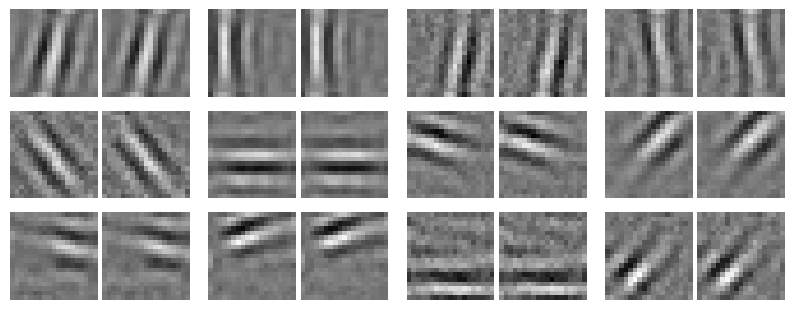

In [210]:
weights=subR.W[-1,:,:]
num_neurons=len(weights)
rf_size=RR[subR.sfname].rf_size

W=weights.reshape((num_neurons,
                    2,
                    rf_size,rf_size))

vmin,vmax=W.min(),W.max()

count=0
blocks=[]
for row in range(3):
    block_row=[]
    for col in range(4):

        for channel in range(2):
            rf=W[count,channel,:,:]
            block_row.append(rf)
            if channel<(2-1):
                block_row.append(vmax*ones((rf_size,1)))

        if col<4-1:
            block_row.append(vmax*ones((rf_size,4)))
    
        count+=1

    blocks.append(block_row)

    buffer_row=[vmax*ones((3,_.shape[1])) for _ in block_row]
    if row<3-1:
        blocks.append(buffer_row)


im=np.block(blocks)

figure()
imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
grid(None)
axis('off')

In [211]:
blur_arr=arange(0,6.1,0.25)
#blur_arr=blur_arr[:20]

In [212]:
len(arange(0,6.1,0.25))

25

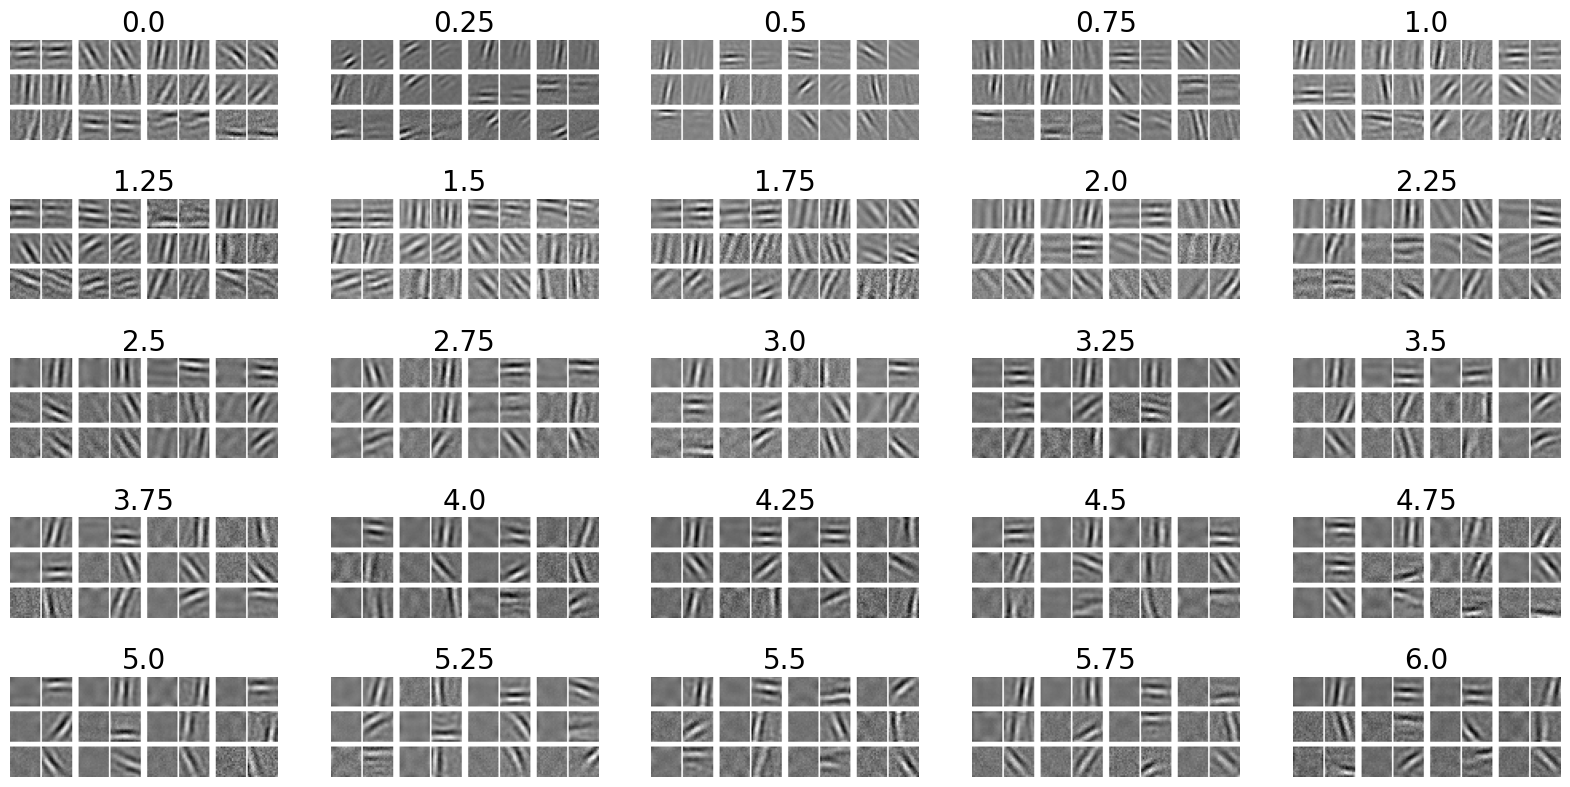

In [213]:
figure(figsize=(20,10))
for i,blur in enumerate(blur_arr):
    sfname=f"{base_sim_dir}/rf2_blur_{blur:.1f}.asdf"
    subR=subResults[sfname]


    weights=subR.W[-1,:,:]
    num_neurons=len(weights)
    rf_size=RR[subR.sfname].rf_size
    
    W=weights.reshape((num_neurons,
                        2,
                        rf_size,rf_size))
    
    vmin,vmax=W.min(),W.max()
    
    count=0
    blocks=[]
    for row in range(3):
        block_row=[]
        for col in range(4):
    
            for channel in range(2):
                rf=W[count,channel,:,:]
                block_row.append(rf)
                if channel<(2-1):
                    block_row.append(vmax*ones((rf_size,1)))
    
            if col<4-1:
                block_row.append(vmax*ones((rf_size,4)))
        
            count+=1
    
        blocks.append(block_row)
    
        buffer_row=[vmax*ones((3,_.shape[1])) for _ in block_row]
        if row<3-1:
            blocks.append(buffer_row)
    
    
    im=np.block(blocks)

    subplot(5,5,i+1)
    imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
    grid(None)
    axis('off')
    title(blur)

In [214]:
def mysubplot(nr,nc,r,c=None):
    from pylab import subplot,subplot2grid

    if c is None:
        subplot(nr,nc,r)
        return
    
    subplot2grid((nr,nc),(r-1,c-1))
    return


In [215]:
rf_size

19

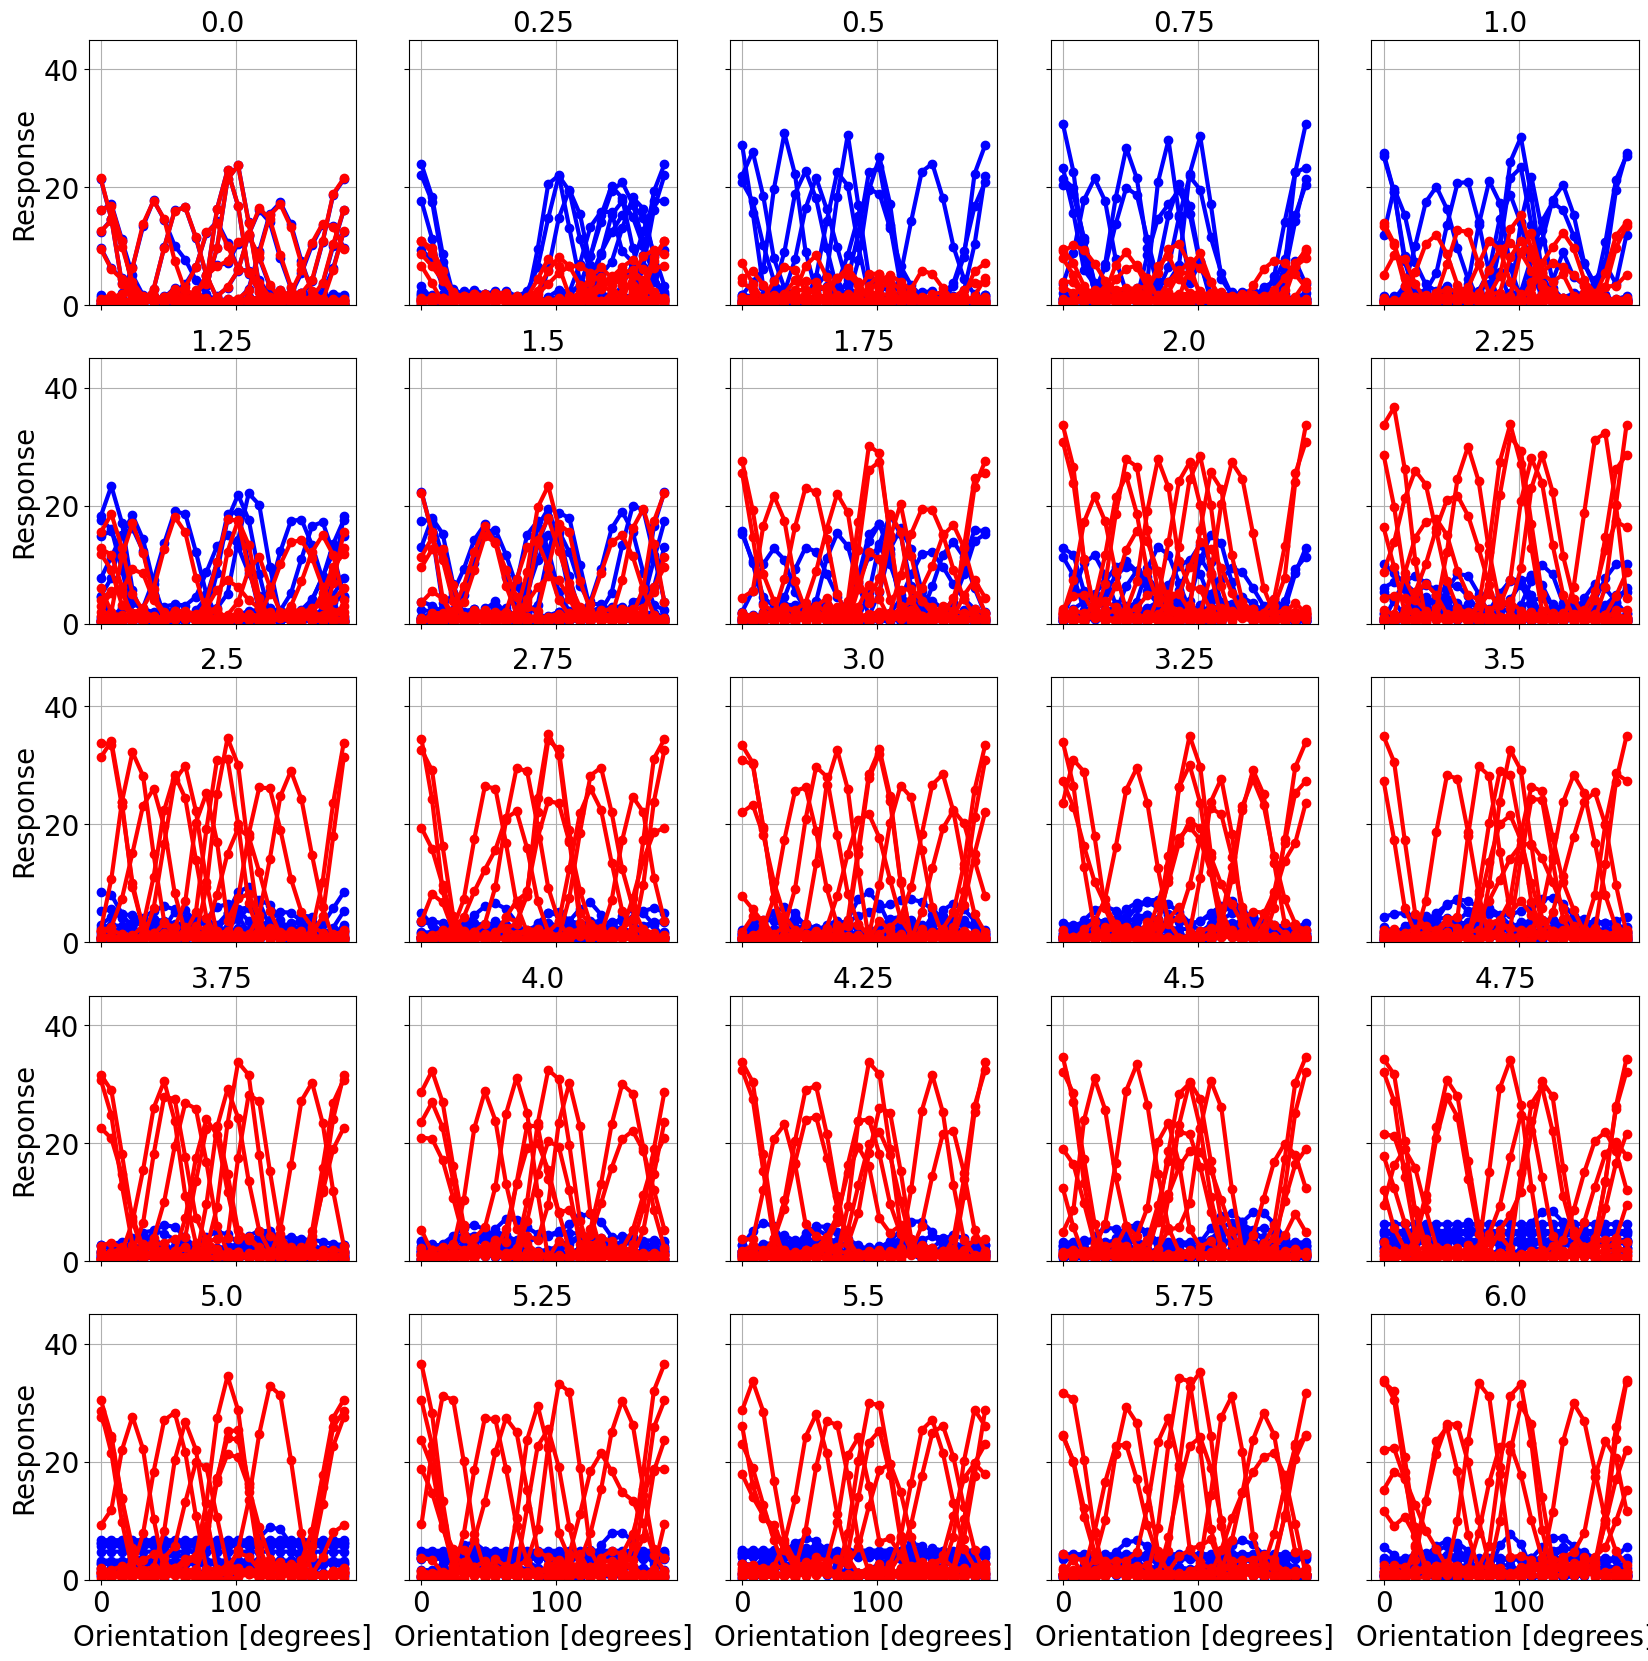

In [216]:
figure(figsize=(20,20))
for bi,blur in enumerate(blur_arr):
    sfname=f"{base_sim_dir}/rf2_blur_{blur:.1f}.asdf"
    subR=subResults[sfname]
    t,y=RR[sfname].all_responses[0]
    y=y[:,:,:,:,-1]  # last time

    ch_idx=[]
    for channel in range(2):
        idx=[]
        for n in range(y.shape[3]):
            idx+=[argmax(y[:,:,channel,n])]  # max across all angles and SF
        ch_idx.append(idx)
    
    theta_mat=subR.theta_mat
    k_mat=subR.k_mat

    ch_result=[]
    
    for channel in range(2):
        idx=ch_idx[channel]
        
        i,j=meshgrid(range(len(theta_mat)),range(len(k_mat)))
        _S=Storage()
        
        max_k_idx=[]
        max_theta_idx=[]
        
        for n in range(y.shape[3]):
            max_k_idx=j.ravel()[idx[n]]
            max_theta_idx=i.ravel()[idx[n]]
            max_k=k_mat[max_k_idx]
            max_theta=theta_mat[max_theta_idx]
        
            _S+=max_k,max_theta,max_k_idx,max_theta_idx
        
        max_k,max_theta,max_k_idx,max_theta_idx=_S.arrays()
    
        ch_result.append( [max_k,max_theta,max_k_idx,max_theta_idx] )

    subplot(5,5,bi+1)
    
    for channel in range(2):
        max_k,max_theta,max_k_idx,max_theta_idx=ch_result[channel]
        
        colors=['b','r']
        for n in range(y.shape[3]):
            plot(theta_mat,y[:,:,channel,n][max_k_idx[n],:],'-o'+colors[channel])

    if bi in [20,21,22,23,24]:
        xlabel('Orientation [degrees]')
    else:
        gca().set_xticklabels([])

    gca().set_ylim([0,45])
    
    if bi in [0,5,10,15,20]:
        ylabel('Response')
    else:
        gca().set_yticklabels([])

    title(blur)

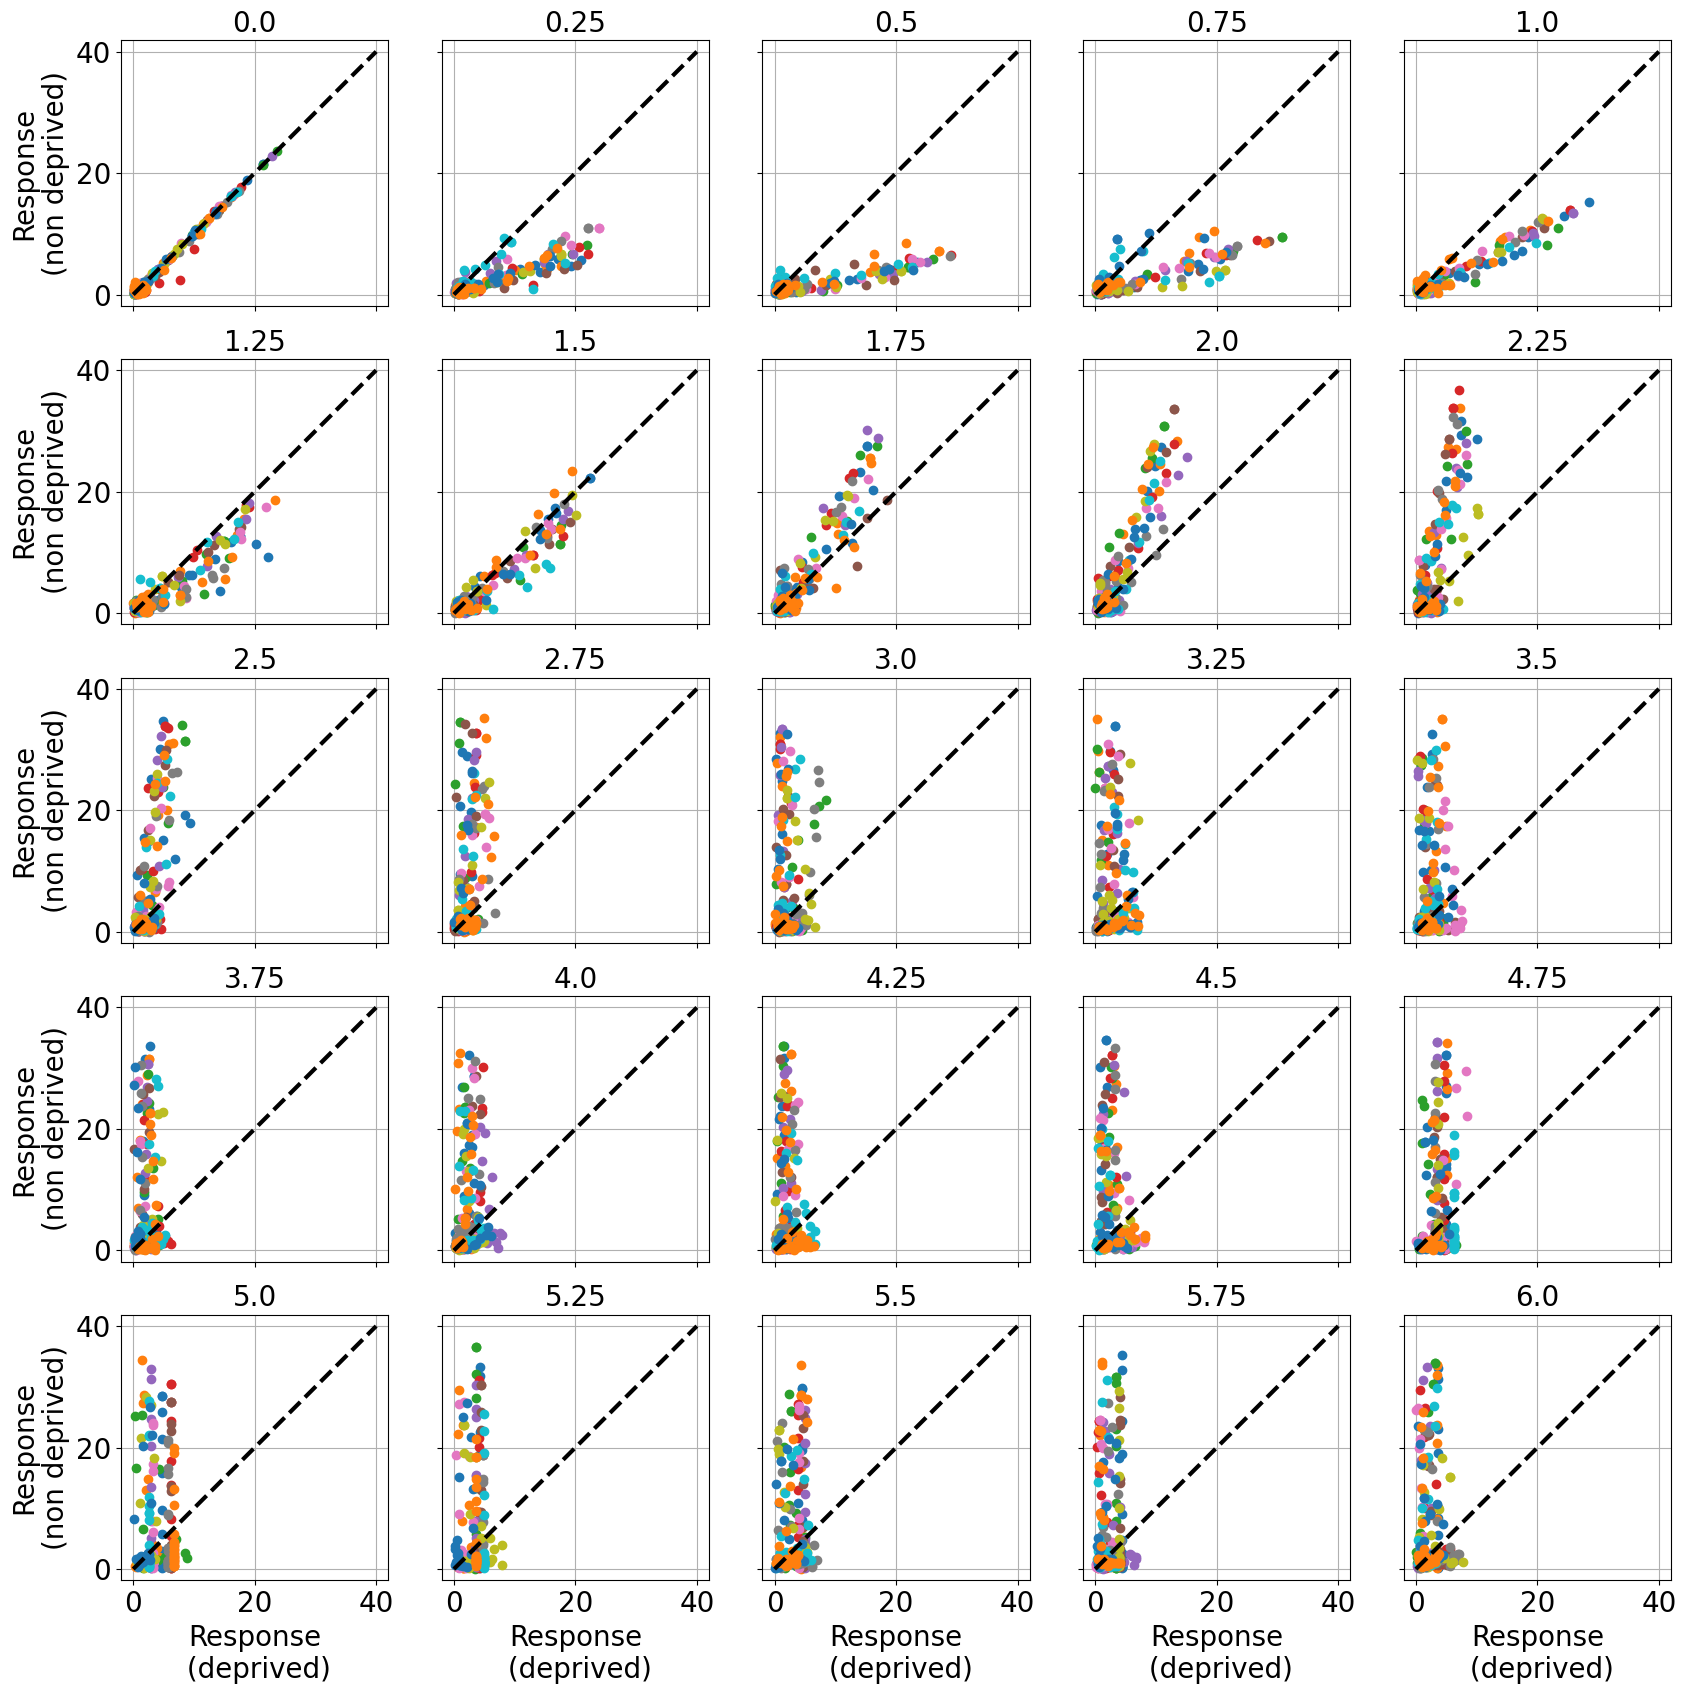

In [217]:
figure(figsize=(20,20))
for bi,blur in enumerate(blur_arr):
    sfname=f"{base_sim_dir}/rf2_blur_{blur:.1f}.asdf"
    subR=subResults[sfname]
    t,y=RR[sfname].all_responses[0]
    y=y[:,:,:,:,-1]  # last time

    ch_idx=[]
    for channel in range(2):
        idx=[]
        for n in range(y.shape[3]):
            idx+=[argmax(y[:,:,channel,n])]  # max across all angles and SF
        ch_idx.append(idx)
    
    theta_mat=subR.theta_mat
    k_mat=subR.k_mat

    ch_result=[]
    
    for channel in range(2):
        idx=ch_idx[channel]
        
        i,j=meshgrid(range(len(theta_mat)),range(len(k_mat)))
        _S=Storage()
        
        max_k_idx=[]
        max_theta_idx=[]
        
        for n in range(y.shape[3]):
            max_k_idx=j.ravel()[idx[n]]
            max_theta_idx=i.ravel()[idx[n]]
            max_k=k_mat[max_k_idx]
            max_theta=theta_mat[max_theta_idx]
        
            _S+=max_k,max_theta,max_k_idx,max_theta_idx
        
        max_k,max_theta,max_k_idx,max_theta_idx=_S.arrays()
    
        ch_result.append( [max_k,max_theta,max_k_idx,max_theta_idx] )

    subplot(5,5,bi+1)

    for n in range(y.shape[3]):
        vecs=[]
        for channel in range(2):
            max_k,max_theta,max_k_idx,max_theta_idx=ch_result[channel]
            vecs.append(y[:,:,channel,n][max_k_idx[n],:])
            
        plot(vecs[0],vecs[1],'o')

    if bi in [20,21,22,23,24]:
        xlabel('Response\n (deprived)')
    else:
        gca().set_xticklabels([])

    gca().set_ylim([0,40])
    gca().set_xlim([0,40])
    plot([0,40],[0,40],'k--')
    axis('equal')
    
    if bi in [0,5,10,15,20]:
        ylabel('Response\n(non deprived)')
    else:
        gca().set_yticklabels([])

    title(blur)

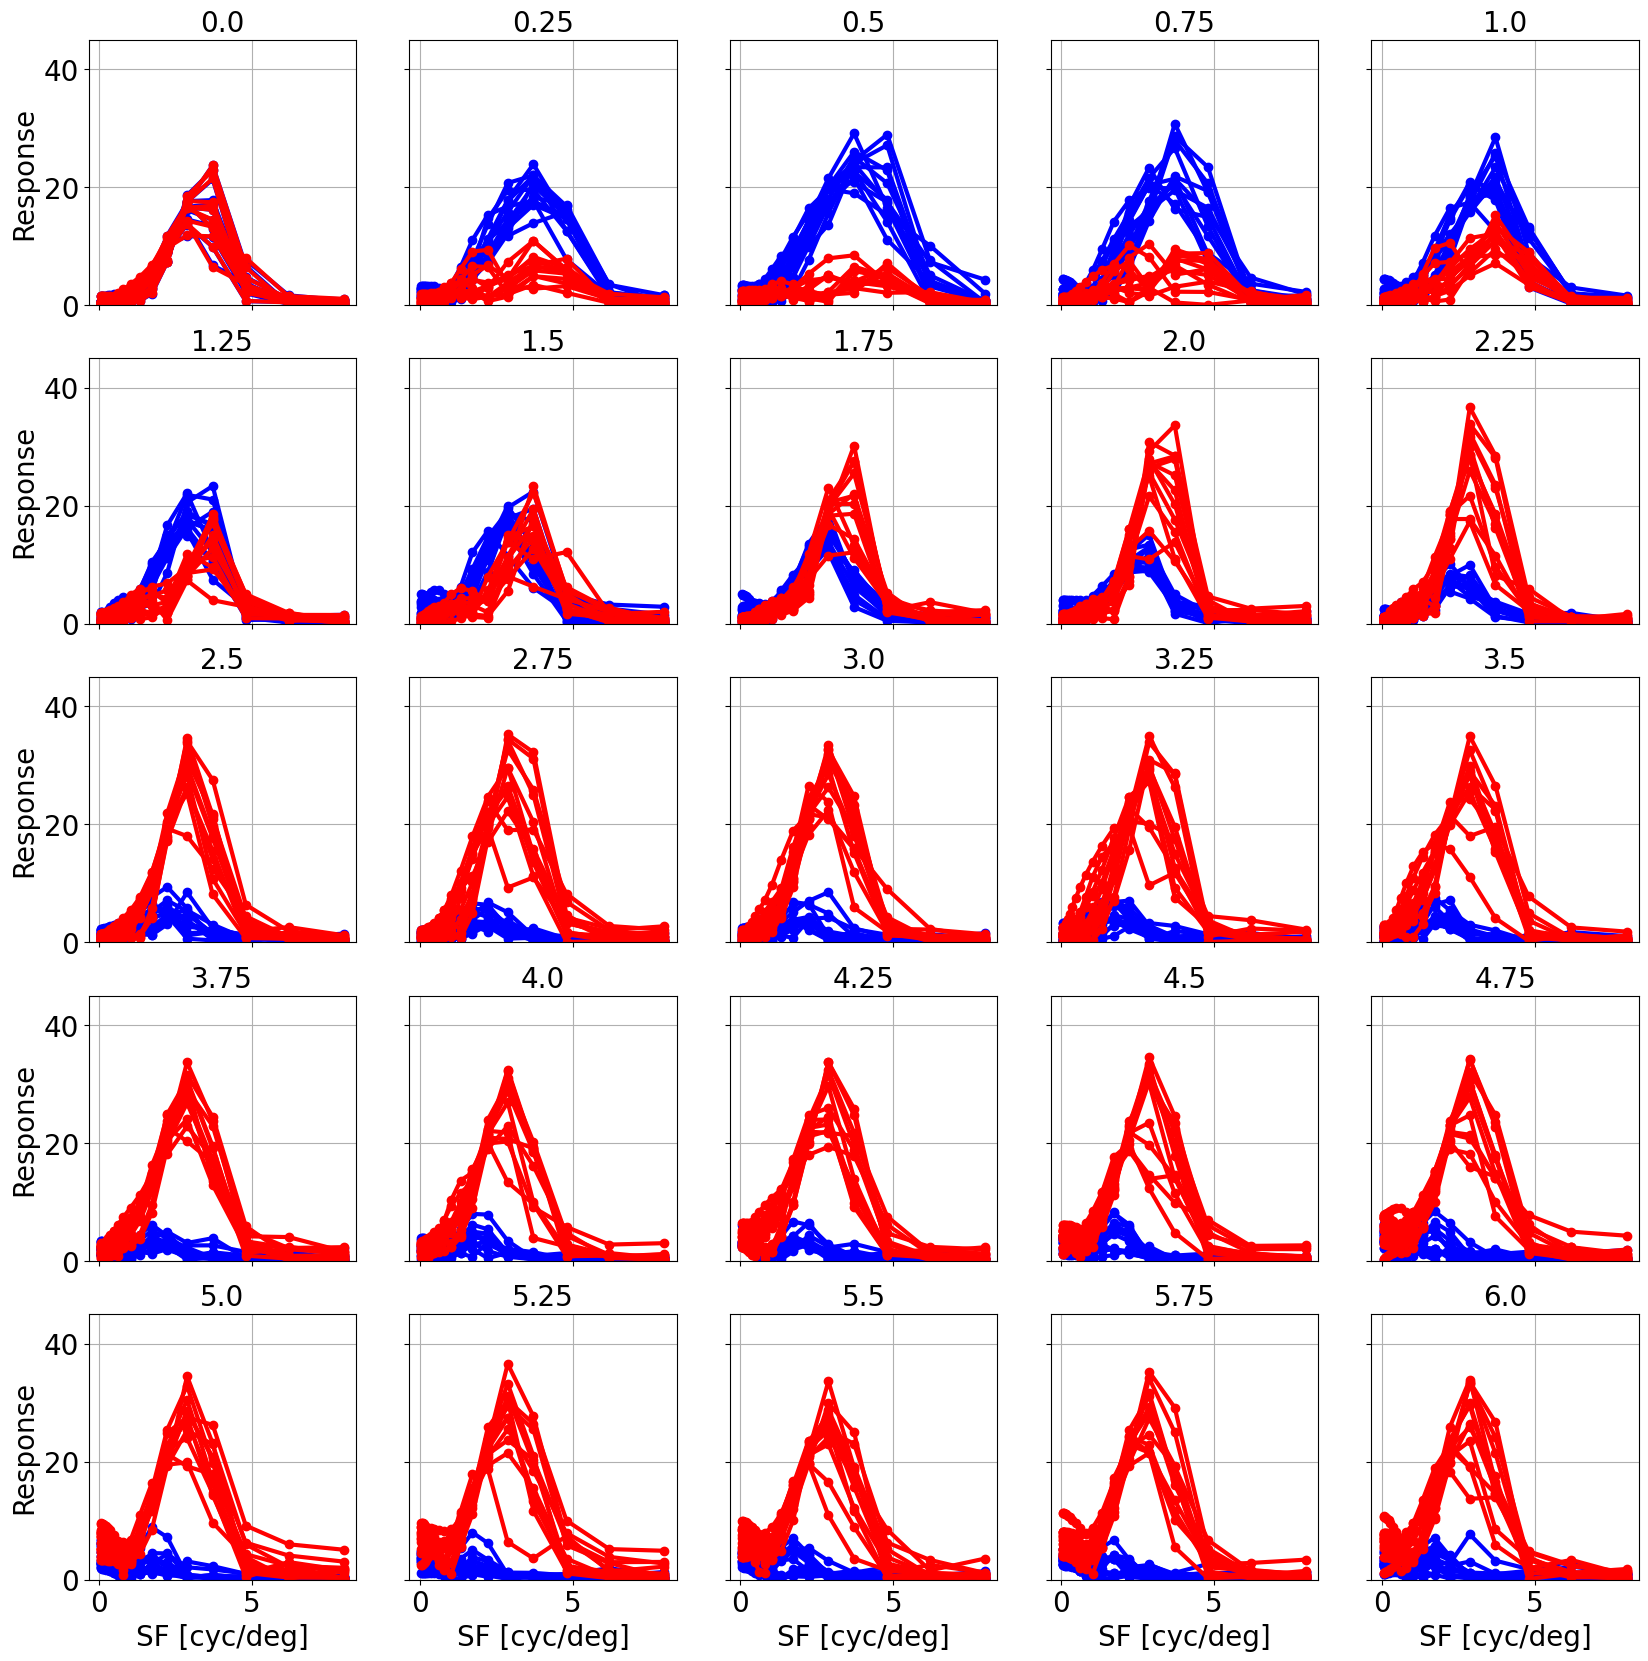

In [218]:
figure(figsize=(20,20))
for bi,blur in enumerate(blur_arr):
    sfname=f"{base_sim_dir}/rf2_blur_{blur:.1f}.asdf"
    subR=subResults[sfname]
    t,y=RR[sfname].all_responses[0]
    y=y[:,:,:,:,-1]  # last time

    ch_idx=[]
    for channel in range(2):
        idx=[]
        for n in range(y.shape[3]):
            idx+=[argmax(y[:,:,channel,n])]  # max across all angles and SF
        ch_idx.append(idx)
    
    theta_mat=subR.theta_mat
    k_mat=subR.k_mat

    ch_result=[]
    
    for channel in range(2):
        idx=ch_idx[channel]
        
        i,j=meshgrid(range(len(theta_mat)),range(len(k_mat)))
        _S=Storage()
        
        max_k_idx=[]
        max_theta_idx=[]
        
        for n in range(y.shape[3]):
            max_k_idx=j.ravel()[idx[n]]
            max_theta_idx=i.ravel()[idx[n]]
            max_k=k_mat[max_k_idx]
            max_theta=theta_mat[max_theta_idx]
        
            _S+=max_k,max_theta,max_k_idx,max_theta_idx
        
        max_k,max_theta,max_k_idx,max_theta_idx=_S.arrays()
    
        ch_result.append( [max_k,max_theta,max_k_idx,max_theta_idx] )

    subplot(5,5,bi+1)
    
    for channel in range(2):
        max_k,max_theta,max_k_idx,max_theta_idx=ch_result[channel]

        rf_diameter=rf_size
        deg_per_pixel=1/rf_diameter  # <=============
        
        cpd=k_mat/(2*pi*deg_per_pixel)
        max_cpd=max_k/(2*pi*deg_per_pixel)
    
        colors=['b','r']
        for n in range(y.shape[3]):
            plot(cpd,y[:,:,channel,n][:,max_theta_idx[n]],'-o'+colors[channel])
        

    if bi in [20,21,22,23,24]:
        xlabel('SF [cyc/deg]')
    else:
        gca().set_xticklabels([])

    gca().set_ylim([0,45])
    
    if bi in [0,5,10,15,20]:
        ylabel('Response')
    else:
        gca().set_yticklabels([])

    title(blur)

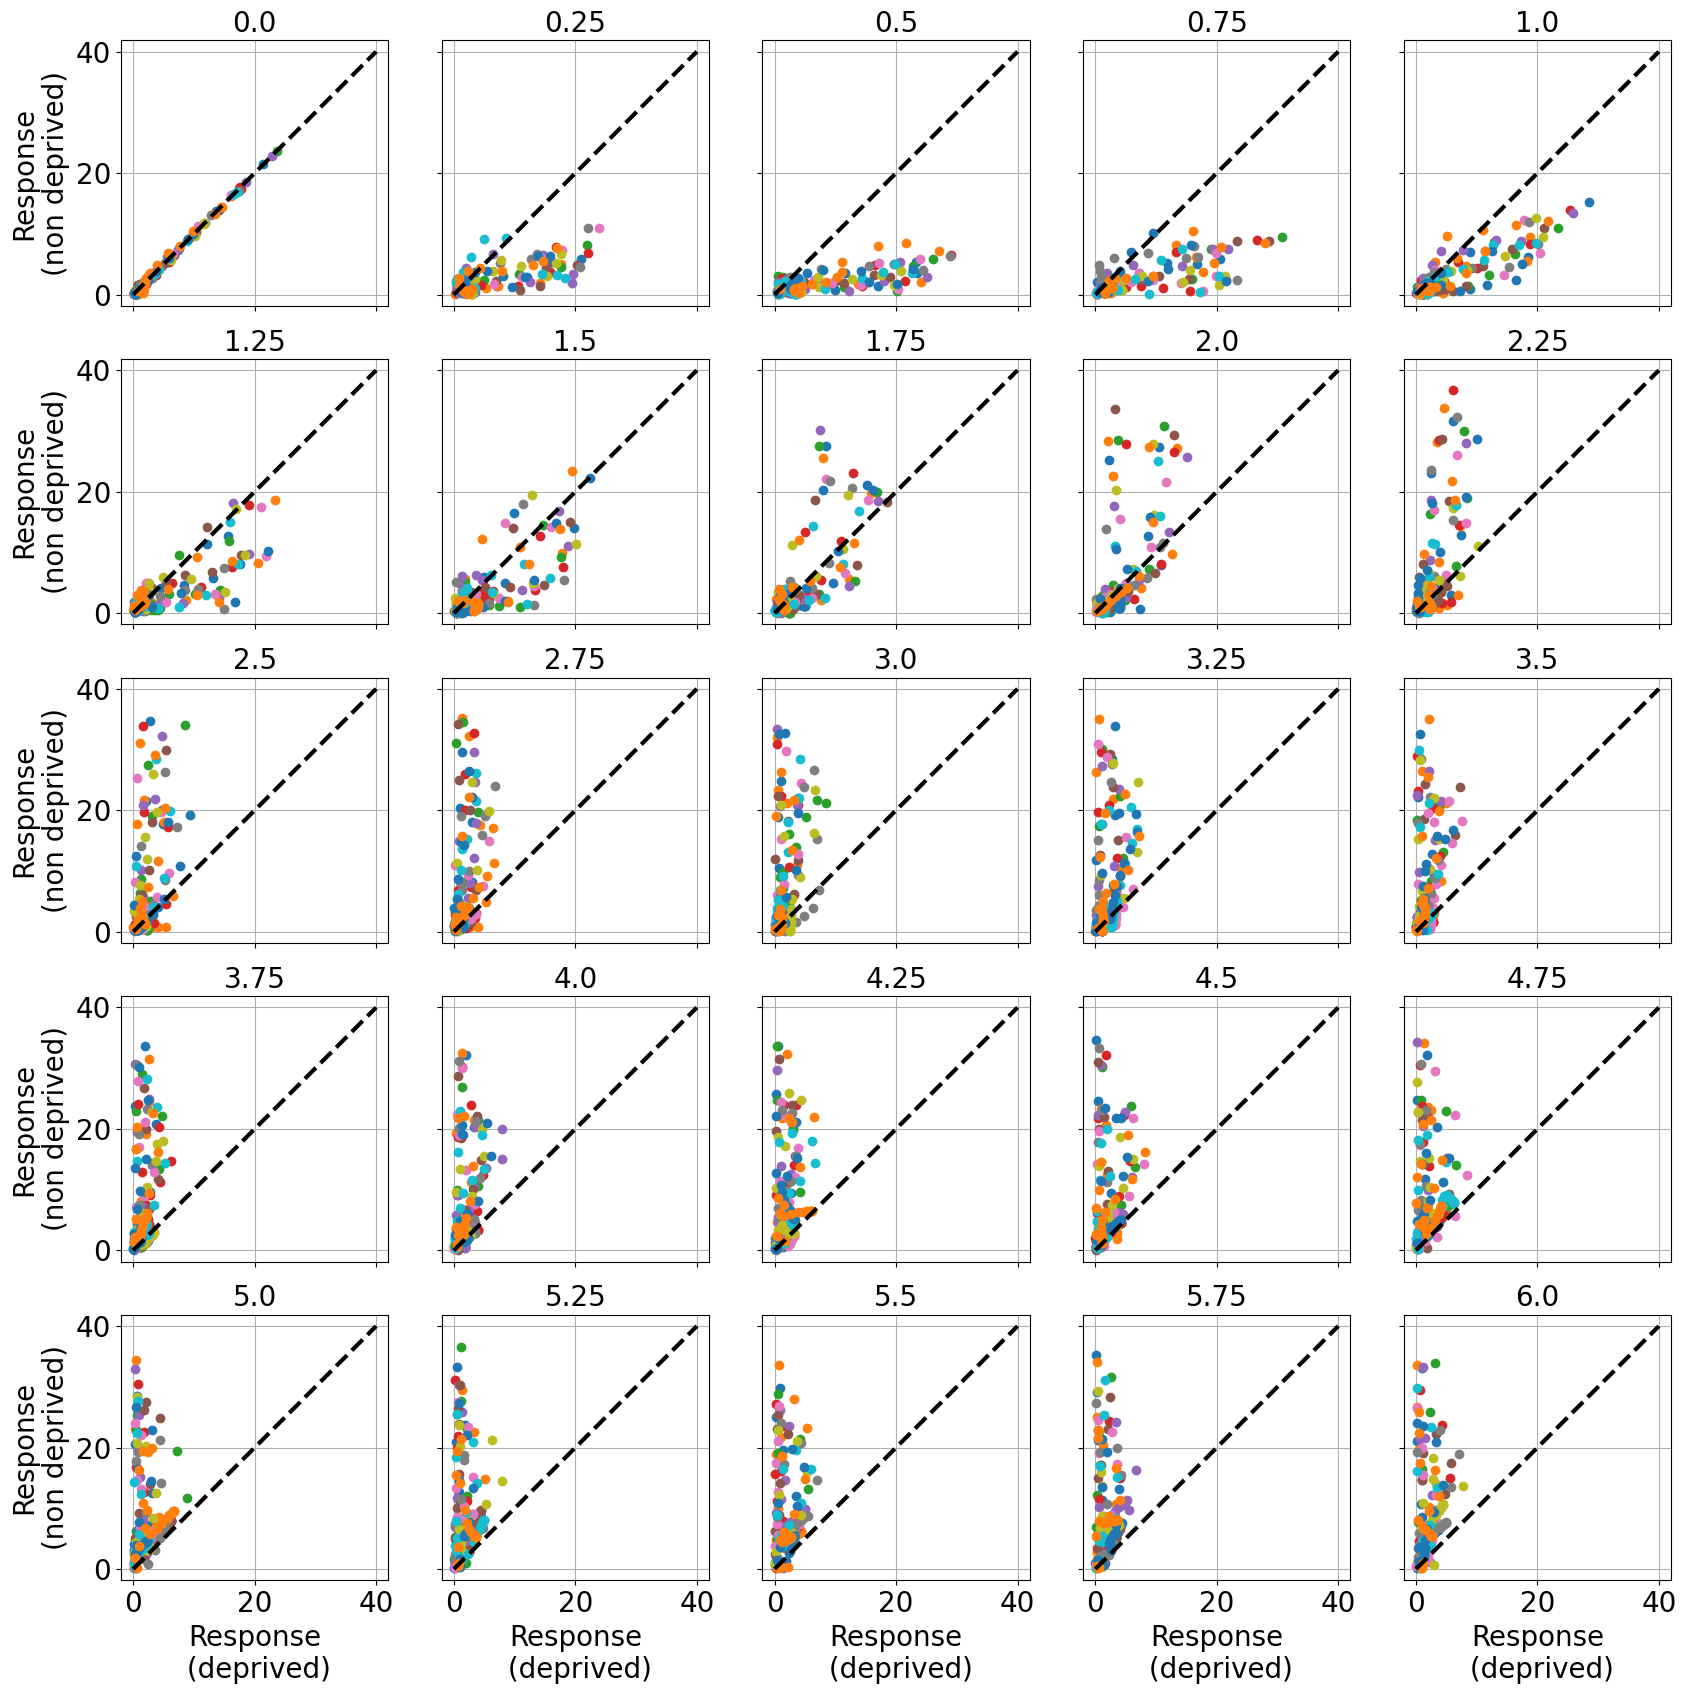

In [219]:
figure(figsize=(20,20))
_S2=Storage()
for bi,blur in enumerate(blur_arr):
    sfname=f"{base_sim_dir}/rf2_blur_{blur:.1f}.asdf"
    subR=subResults[sfname]
    t,y=RR[sfname].all_responses[0]
    y=y[:,:,:,:,-1]  # last time

    ch_idx=[]
    for channel in range(2):
        idx=[]
        for n in range(y.shape[3]):
            idx+=[argmax(y[:,:,channel,n])]  # max across all angles and SF
        ch_idx.append(idx)
    
    theta_mat=subR.theta_mat
    k_mat=subR.k_mat

    ch_result=[]
    
    for channel in range(2):
        idx=ch_idx[channel]
        
        i,j=meshgrid(range(len(theta_mat)),range(len(k_mat)))
        _S=Storage()
        
        max_k_idx=[]
        max_theta_idx=[]
        
        for n in range(y.shape[3]):
            max_k_idx=j.ravel()[idx[n]]
            max_theta_idx=i.ravel()[idx[n]]
            max_k=k_mat[max_k_idx]
            max_theta=theta_mat[max_theta_idx]
        
            _S+=max_k,max_theta,max_k_idx,max_theta_idx
        
        max_k,max_theta,max_k_idx,max_theta_idx=_S.arrays()
    
        ch_result.append( [max_k,max_theta,max_k_idx,max_theta_idx] )

    subplot(5,5,bi+1)

    rf_diameter=rf_size
    deg_per_pixel=1/rf_diameter  # <=============
    
    cpd=k_mat/(2*pi*deg_per_pixel)
    max_cpd=max_k/(2*pi*deg_per_pixel)

    for n in range(y.shape[3]):
        vecs=[]
        for channel in range(2):
            max_k,max_theta,max_k_idx,max_theta_idx=ch_result[channel]
            vecs.append(y[:,:,channel,n][:,max_theta_idx[n]])
            
        plot(vecs[0],vecs[1],'o')
                

    if bi in [20,21,22,23,24]:
        xlabel('Response\n (deprived)')
    else:
        gca().set_xticklabels([])

    gca().set_ylim([0,40])
    gca().set_xlim([0,40])
    plot([0,40],[0,40],'k--')
    axis('equal')
    
    if bi in [0,5,10,15,20]:
        ylabel('Response\n(non deprived)')
    else:
        gca().set_yticklabels([])

    title(blur)

    μσ_max_cpd=[None,None]
    for channel in range(2):
        max_k,max_theta,max_k_idx,max_theta_idx=ch_result[channel]
        cpd=k_mat/(2*pi*deg_per_pixel)
        max_cpd=max_k/(2*pi*deg_per_pixel)
        μσ_max_cpd[channel]=μσ(max_cpd)
    _S2+=blur,μσ_max_cpd[0][0],μσ_max_cpd[1][0],μσ_max_cpd[0][1],μσ_max_cpd[1][1]

Text(0.5, 0, 'Blur [pixesls]')

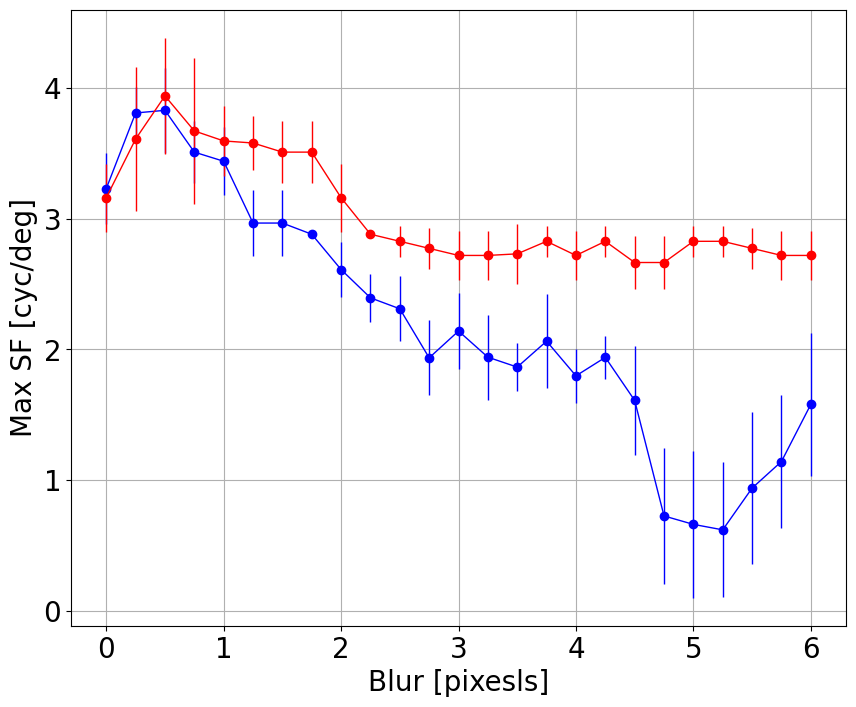

In [220]:
blur,μ0,μ1,σ0,σ1=_S2.arrays()
errorbar(blur,μ0,yerr=2*σ0,color='b',lw=1,marker='o')
errorbar(blur,μ1,yerr=2*σ1,color='r',lw=1,marker='o')
ylabel('Max SF [cyc/deg]')
xlabel('Blur [pixesls]')

looks like a blur>2.5 is needed to get something with an appreciable difference in SF.  but, above 4 the RF for the deprived channel is basically garbage. 